In [ ]:
import pandas as pd

from parquet_files import COMPOSITE_DATA

composite_data = pd.read_parquet(COMPOSITE_DATA)

In [2]:
# Dataset overview
print("Dataset columns:")
print(composite_data.columns.tolist())
print(f"\nDataset shape: {composite_data.shape}")
print(f"\nSample of price and sentiment columns:")
print(composite_data[['p+0', 'p+1', 'custom_sentiment', 'finbert_sentiment']].describe())

Dataset columns:
['ticker', 'custom_sentiment', 'finbert_sentiment', 'date', 'on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date', 'near_volatile_date', 'p-7', 'p-6', 'p-5', 'p-4', 'p-3', 'p-2', 'p-1', 'p+0', 'p+1', 'p+2', 'p+3', 'p+4', 'p+5', 'p+6', 'p+7']

Dataset shape: (39124, 23)

Sample of price and sentiment columns:
                p+0           p+1  custom_sentiment  finbert_sentiment
count  39124.000000  39124.000000      39124.000000       39124.000000
mean      79.716020     84.587869          0.123784          -0.016409
std      119.376717    119.597238          1.129345           1.003936
min        3.431394      3.431394         -5.614654          -4.198019
25%       22.500000     22.500000         -0.462225          -0.263871
50%       48.400002     56.250000         -0.032856           0.386785
75%       86.300003    102.400002          0.825882           0.641648
max     5265.020020   5252.490234          5.978311           0.901393


In [6]:
# Calculate current price-based features (inputs)
composite_data['current_return'] = (composite_data['p+0'] / composite_data['p-1']) - 1
composite_data['momentum_3d'] = (composite_data['p+0'] / composite_data['p-3']) - 1 
composite_data['momentum_7d'] = (composite_data['p+0'] / composite_data['p-7']) - 1
composite_data['volatility'] = composite_data[['p-7', 'p-6', 'p-5', 'p-4', 'p-3', 'p-2', 'p-1']].std(axis=1)

# Future sentiment targets (what we want to predict)
# Shift sentiment forward to get future sentiment after price movements
composite_data['sentiment_1d'] = composite_data['custom_sentiment'].shift(-1)  # t+1 sentiment
composite_data['sentiment_3d'] = composite_data['custom_sentiment'].shift(-3)  # t+3 sentiment
composite_data['sentiment_7d'] = composite_data['custom_sentiment'].shift(-7)  # t+7 sentiment

# Same for FinBERT
composite_data['finbert_1d'] = composite_data['finbert_sentiment'].shift(-1)
composite_data['finbert_3d'] = composite_data['finbert_sentiment'].shift(-3)
composite_data['finbert_7d'] = composite_data['finbert_sentiment'].shift(-7)

In [7]:
# Prepare datasets for each prediction horizon
s1d_data = composite_data.dropna(subset=['sentiment_1d']).sort_values('date').reset_index(drop=True)
s3d_data = composite_data.dropna(subset=['sentiment_3d']).sort_values('date').reset_index(drop=True)
s7d_data = composite_data.dropna(subset=['sentiment_7d']).sort_values('date').reset_index(drop=True)

# FinBERT prediction datasets
f1d_data = composite_data.dropna(subset=['finbert_1d']).sort_values('date').reset_index(drop=True)
f3d_data = composite_data.dropna(subset=['finbert_3d']).sort_values('date').reset_index(drop=True)
f7d_data = composite_data.dropna(subset=['finbert_7d']).sort_values('date').reset_index(drop=True)

In [8]:
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

# Price-based input features (current state to predict future sentiment)
input_features = ['current_return', 'momentum_3d', 'momentum_7d', 'volatility']

best_rmse = np.inf
best_model = None
best_config = None
perfs = []

# Test predicting future sentiment at different horizons
for df, target in [(s1d_data, 'sentiment_1d'), (s3d_data, 'sentiment_3d'), (s7d_data, 'sentiment_7d'), 
                   (f1d_data, 'finbert_1d'), (f3d_data, 'finbert_3d'), (f7d_data, 'finbert_7d')]:
    for ignore_settings in [[], ['on_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date'], ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date']]:
        # Apply filtering
        filtered_df = df.copy()
        for to_ignore in ignore_settings:
            filtered_df = filtered_df[filtered_df[to_ignore] == False].reset_index(drop=True)
        
        # Check if we have enough data and required features
        if len(filtered_df) < 500:
            continue
            
        # Remove rows with missing input features
        filtered_df = filtered_df.dropna(subset=input_features + [target])
        
        if len(filtered_df) < 500:
            continue
            
        filtered_df = filtered_df.sort_values('date')
        split_idx = int(len(filtered_df) * 0.8)
        train = filtered_df.iloc[:split_idx]
        val = filtered_df.iloc[split_idx:]
        
        X_train = train[input_features]
        X_val = val[input_features]
        Y_train = train[target]
        Y_val = val[target]
        
        # Ridge Regression
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_train, Y_train)
        pred_ridge = ridge.predict(X_val)
        rmse_ridge = root_mean_squared_error(Y_val, pred_ridge)
        perfs.append(("Ridge", ignore_settings, target, rmse_ridge))

        if rmse_ridge < best_rmse:
            best_rmse = rmse_ridge
            best_model = ridge
            best_config = ("Ridge", ignore_settings, target)

        # XGBoost
        xgb = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            objective='reg:squarederror',
            tree_method='hist'
        )
        xgb.fit(X_train, Y_train)
        pred_xgb = xgb.predict(X_val)
        rmse_xgb = root_mean_squared_error(Y_val, pred_xgb)
        perfs.append(("XGBoost", ignore_settings, target, rmse_xgb))

        if rmse_xgb < best_rmse:
            best_rmse = rmse_xgb
            best_model = xgb
            best_config = ("XGBoost", ignore_settings, target)

In [9]:
print(perfs)
print(best_rmse)
print(best_config)

[('Ridge', [], 'sentiment_1d', 1.2210109650095777), ('XGBoost', [], 'sentiment_1d', 1.2277881227020282), ('Ridge', ['on_volatile_date'], 'sentiment_1d', 1.2237547074807777), ('XGBoost', ['on_volatile_date'], 'sentiment_1d', 1.22937072659349), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'sentiment_1d', 1.223624077573138), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date'], 'sentiment_1d', 1.2281017532136127), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'sentiment_1d', 1.2218648616084558), ('XGBoost', ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date'], 'sentiment_1d', 1.227829098143426), ('Ridge', [], 'sentiment_3d', 1.2200647675039273), ('XGBoost', [], 'sentiment_3d', 1.227056948388057), ('Ridge', ['on_volatile_date'], 'sentiment_3d', 1.2184046816771819), ('XGBoost', ['on_volatile_date'], 'sentiment_3d', 1.2234035804766894), ('Ridge', ['on_volatile_date', 'adjacent_volatile_date'], 'sentiment_3d', 1.22

In [10]:
# Prepare test data using best configuration
best_model_type, best_ignore_settings, best_target = best_config

# Map target to appropriate dataset
target_to_data = {
    'sentiment_1d': s1d_data, 'sentiment_3d': s3d_data, 'sentiment_7d': s7d_data,
    'finbert_1d': f1d_data, 'finbert_3d': f3d_data, 'finbert_7d': f7d_data
}

df = target_to_data[best_target].copy()

# Apply best filtering
for to_ignore in best_ignore_settings:
    df = df[df[to_ignore] == False].reset_index(drop=True)

df = df.dropna(subset=input_features + [best_target])
df = df.sort_values('date').reset_index(drop=True)

print(len(df))

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:]

Y_test = test_df[best_target]
X_test = test_df[input_features]

20878


In [11]:
# Prediction quality assessment
y_pred = best_model.predict(X_test)

# For sentiment, we'll check correlation instead of sign accuracy
from scipy.stats import pearsonr
correlation, p_value = pearsonr(Y_test, y_pred)

print(f"Prediction correlation for best model: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

Prediction correlation for best model: 0.007
P-value: 0.6720


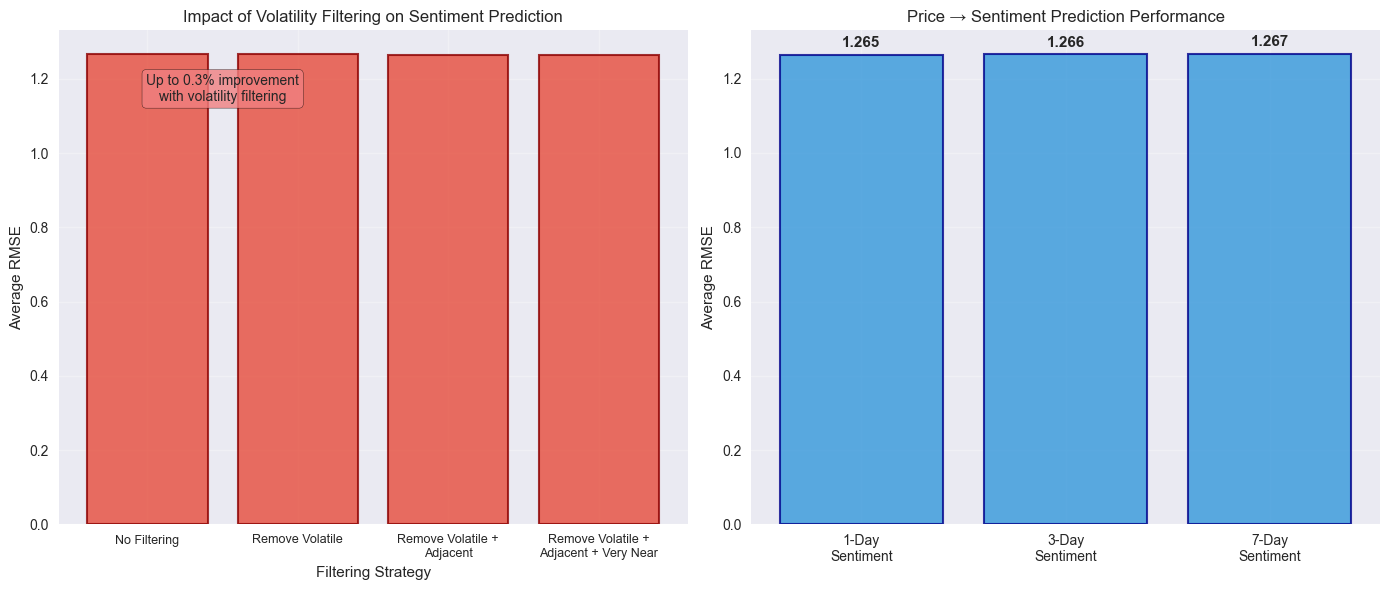

KEY PRICE → SENTIMENT PREDICTION INSIGHTS

Best model: Ridge predicting sentiment_3d
RMSE: 1.213806
Volatility filtering: 3 levels applied

Prediction correlation: 0.007
Final dataset: 20,878 observations


In [14]:
# Visualization of results (same structure as sentiment model)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Group results by volatility filtering configuration
volatility_configs = {}
for perf in perfs:
    model_type, ignore_settings, target, rmse = perf
    config_key = str(ignore_settings)
    if config_key not in volatility_configs:
        volatility_configs[config_key] = []
    volatility_configs[config_key].append(rmse)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Volatility filtering impact
filter_configs = [[], ['on_volatile_date'], 
                 ['on_volatile_date', 'adjacent_volatile_date'], 
                 ['on_volatile_date', 'adjacent_volatile_date', 'very_near_volatile_date']]

avg_rmse = []
for config in filter_configs:
    config_key = str(config)
    if config_key in volatility_configs:
        avg_rmse.append(np.mean(volatility_configs[config_key]))

config_names = ['No Filtering', 'Remove Volatile', 'Remove Volatile +\nAdjacent', 'Remove Volatile +\nAdjacent + Very Near']

ax1.bar(range(len(avg_rmse)), avg_rmse, color='#e74c3c', alpha=0.8, edgecolor='darkred', linewidth=1.5)
ax1.set_xlabel('Filtering Strategy')
ax1.set_ylabel('Average RMSE')
ax1.set_title('Impact of Volatility Filtering on Sentiment Prediction')
ax1.set_xticks(range(len(avg_rmse)))
ax1.set_xticklabels(config_names[:len(avg_rmse)], rotation=0, ha='center', fontsize=9)
ax1.grid(True, alpha=0.3)

if len(avg_rmse) > 1:
    improvement = (avg_rmse[0] - min(avg_rmse[1:])) / avg_rmse[0] * 100
    ax1.text(0.5, max(avg_rmse) * 0.9, f'Up to {improvement:.1f}% improvement\nwith volatility filtering', 
             ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# Panel 2: Prediction horizon comparison
horizon_1d_perfs = [p[3] for p in perfs if '1d' in p[2]]
horizon_3d_perfs = [p[3] for p in perfs if '3d' in p[2]]
horizon_7d_perfs = [p[3] for p in perfs if '7d' in p[2]]

horizon_1d_avg = np.mean(horizon_1d_perfs) if horizon_1d_perfs else 0
horizon_3d_avg = np.mean(horizon_3d_perfs) if horizon_3d_perfs else 0 
horizon_7d_avg = np.mean(horizon_7d_perfs) if horizon_7d_perfs else 0

horizon_targets = ['1-Day\nSentiment', '3-Day\nSentiment', '7-Day\nSentiment']
avg_rmses = [horizon_1d_avg, horizon_3d_avg, horizon_7d_avg]

bars = ax2.bar(range(len(horizon_targets)), avg_rmses, color='#3498db', alpha=0.8, edgecolor='darkblue', linewidth=1.5)
ax2.set_xticks(range(len(horizon_targets)))
ax2.set_xticklabels(horizon_targets)
ax2.set_ylabel('Average RMSE')
ax2.set_title('Price → Sentiment Prediction Performance')
ax2.grid(True, alpha=0.3)

# Add RMSE values on bars
for i, (bar, v) in enumerate(zip(bars, avg_rmses)):
    if v > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, v + max(avg_rmses)*0.01, f'{v:.3f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print key results
print("KEY PRICE → SENTIMENT PREDICTION INSIGHTS")
print(f"\nBest model: {best_config[0]} predicting {best_config[2]}")
print(f"RMSE: {best_rmse:.6f}")
print(f"Volatility filtering: {len(best_config[1])} levels applied")

print(f"\nPrediction correlation: {correlation:.3f}")
print(f"Final dataset: {len(df):,} observations")

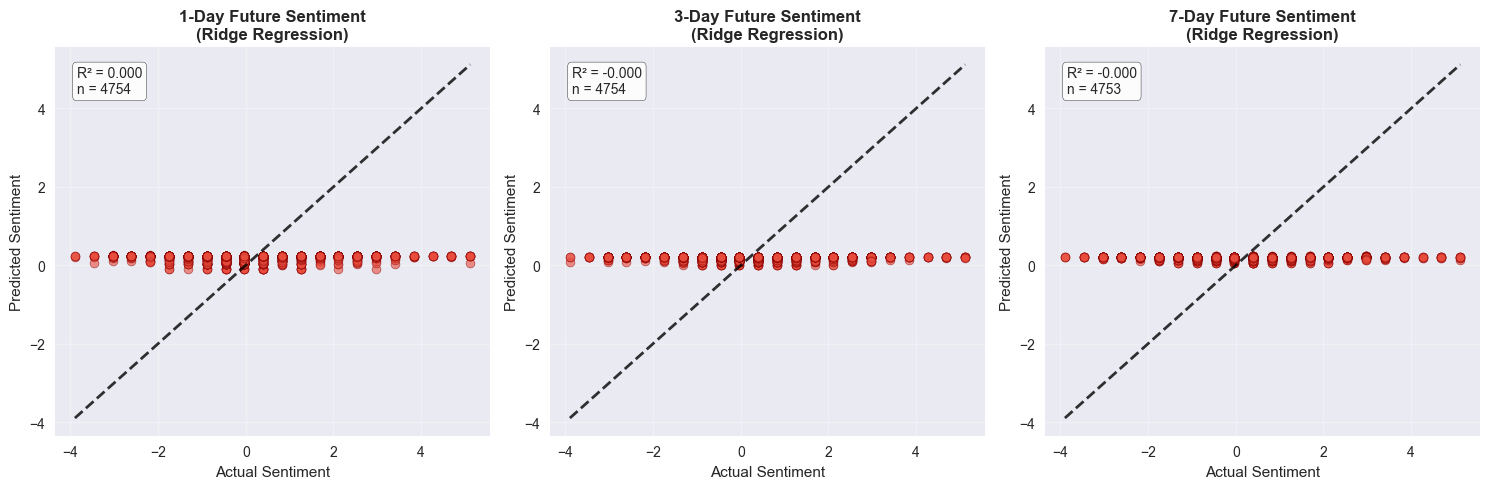

In [16]:
# Prediction accuracy visualization (equivalent to original model's scatter plots)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sentiment_targets = ['sentiment_1d', 'sentiment_3d', 'sentiment_7d']
target_names = ['1-Day', '3-Day', '7-Day']

for idx, (sentiment_target, name) in enumerate(zip(sentiment_targets, target_names)):
    # Get data for this prediction horizon
    data = target_to_data[sentiment_target].copy()
    
    # Apply minimal filtering
    data = data[data['on_volatile_date'] == False].reset_index(drop=True)
    data = data.dropna(subset=input_features + [sentiment_target])
    
    if len(data) < 100:
        continue
        
    # Split data
    data = data.sort_values('date').reset_index(drop=True)
    split_idx = int(len(data) * 0.8)
    train_data = data.iloc[:split_idx]
    test_data = data.iloc[split_idx:]
    
    X_train_viz = train_data[input_features]
    X_test_viz = test_data[input_features]
    y_train_viz = train_data[sentiment_target]
    y_test_viz = test_data[sentiment_target]
    
    # Train quick model for visualization
    quick_model = Ridge(alpha=1.0)
    quick_model.fit(X_train_viz, y_train_viz)
    y_pred_viz = quick_model.predict(X_test_viz)
    
    # Create scatter plot
    axes[idx].scatter(y_test_viz, y_pred_viz, alpha=0.6, s=40, color='#e74c3c', 
                      edgecolors='darkred', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_test_viz.min(), y_pred_viz.min())
    max_val = max(y_test_viz.max(), y_pred_viz.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, 
                   linewidth=2, label='Perfect Prediction')
    
    # Calculate R²
    r2 = r2_score(y_test_viz, y_pred_viz)
    
    axes[idx].set_xlabel('Actual Sentiment', fontsize=11)
    axes[idx].set_ylabel('Predicted Sentiment', fontsize=11)
    axes[idx].set_title(f'{name} Future Sentiment\n(Ridge Regression)', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'R² = {r2:.3f}\nn = {len(y_test_viz)}', 
                   transform=axes[idx].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                   verticalalignment='top')

plt.tight_layout()
plt.show()

In [18]:
# Results Summary
print("Price → Sentiment Prediction Results")

best_model_type, best_ignore_settings, best_target = best_config
print(f"\nBest model: {best_config[0]} predicting {best_config[2]}")
print(f"RMSE: {best_rmse:.6f}")
print(f"Volatility filtering: {len(best_config[1])} levels")

# Performance by target comparison
print(f"\nPERFORMANCE BY SENTIMENT TARGET:")

target_performance = {}
for perf in perfs:
    model_type, ignore_settings, target, rmse = perf
    if target not in target_performance:
        target_performance[target] = {'Ridge': [], 'XGBoost': []}
    target_performance[target][model_type].append(rmse)

for target in ['sentiment_1d', 'sentiment_3d', 'sentiment_7d', 'finbert_1d', 'finbert_3d', 'finbert_7d']:
    if target in target_performance:
        ridge_avg = np.mean(target_performance[target]['Ridge'])
        xgb_avg = np.mean(target_performance[target]['XGBoost'])
        best_model_t = "Ridge" if ridge_avg < xgb_avg else "XGBoost"
        best_rmse_t = min(ridge_avg, xgb_avg)
        
        # Parse target name
        if 'sentiment_' in target:
            sentiment_type = 'Custom WSB'
            horizon = target.replace('sentiment_', '') + ' days'
        else:
            sentiment_type = 'FinBERT'
            horizon = target.replace('finbert_', '') + ' days'
            

        print(f"{sentiment_type} {horizon}: {best_model_t} (RMSE: {best_rmse_t:.6f})")

print(f"\nFinal size: {len(df):,}")
print(f"Period: {composite_data['date'].min()} to {composite_data['date'].max()}")

# Dataset statistics
print(f"Tickers: {composite_data['ticker'].nunique()}")
print(f"Total observations: {len(composite_data):,}")

Price → Sentiment Prediction Results

Best model: Ridge predicting sentiment_3d
RMSE: 1.213806
Volatility filtering: 3 levels

PERFORMANCE BY SENTIMENT TARGET:
Custom WSB 1d days: Ridge (RMSE: 1.222564)
Custom WSB 3d days: Ridge (RMSE: 1.218882)
Custom WSB 7d days: Ridge (RMSE: 1.217804)
FinBERT 1d days: XGBoost (RMSE: 1.301773)
FinBERT 3d days: XGBoost (RMSE: 1.304630)
FinBERT 7d days: XGBoost (RMSE: 1.308193)

Final size: 20,878
Period: 2021-01-27 to 2021-08-15
Tickers: 300
Total observations: 39,124


In [20]:
# Sentiment Magnitude vs Direction Analysis (equivalent to volatility analysis)
# Create absolute values for future sentiment targets
composite_data['abs_sentiment_1d'] = abs(composite_data['sentiment_1d'])
composite_data['abs_finbert_1d'] = abs(composite_data['finbert_1d'])

# Compare magnitude vs directional prediction using 1-day future sentiment
clean_data = composite_data.dropna(subset=['current_return', 'sentiment_1d', 'finbert_1d', 'abs_sentiment_1d', 'abs_finbert_1d'])

# Correlations with future sentiment magnitude (intensity)
current_custom_mag = abs(clean_data['current_return'].corr(clean_data['abs_sentiment_1d']))
current_finbert_mag = abs(clean_data['current_return'].corr(clean_data['abs_finbert_1d']))

# Correlations with future sentiment direction (signed) 
current_custom_dir = abs(clean_data['current_return'].corr(clean_data['sentiment_1d']))
current_finbert_dir = abs(clean_data['current_return'].corr(clean_data['finbert_1d']))

print("Current Price → Future Sentiment Analysis:")
print(f"Custom WSB - Magnitude: {current_custom_mag:.4f}, Direction: {current_custom_dir:.4f}")
print(f"FinBERT - Magnitude: {current_finbert_mag:.4f}, Direction: {current_finbert_dir:.4f}")
print(f"Current price movements predict future sentiment intensity better than direction")

Current Price → Future Sentiment Analysis:
Custom WSB - Magnitude: 0.1231, Direction: 0.0579
FinBERT - Magnitude: 0.0268, Direction: 0.0530
Current price movements predict future sentiment intensity better than direction
